# DATA266 Lab 1 - Task 2
## Yelp polarity sentiment classification (zohebw)

Three models, all with embeddings **learned from scratch** - no pretrained embeddings and no
pretrained language models anywhere in the pipeline.

| | M1 (baseline) | M2 | M3 |
|---|---|---|---|
| Architecture | BiLSTM + mean pooling | multi-kernel TextCNN | BiLSTM + additive attention |
| Changes vs baseline | - | encoder family | depth, width, pooling, schedule |

Training is config-driven (`src/train.py --config configs/<model>.yaml`). **On Colab, section 0
below runs it**; off Colab that section is a no-op and the notebook simply loads completed runs.

Trained on the **full ~540K** Yelp training split (20K held out for validation), matching
shreya_akotiya, so the cross-member comparison in the team report is not confounded by
training-set size.

## 0. Colab: set up and train

Runs only when the notebook is executing on Colab — locally these cells detect no Colab and skip,
so the notebook stays a pure reporting document on a machine that already has the results.

**Use an A100 (or any CUDA GPU).** Expect roughly an hour: ~10–15 min to preprocess 540K reviews
(lemmatisation is single-threaded), then ~2 min for M1, ~2 min for M2 and ~45 min for M3.

If a run dies partway, re-run only the cell for the model that failed — the preprocessing cache
and the finished models' outputs are kept.

In [1]:
# 0.1 environment - no-op off Colab
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "https://github.com/sakotiya/data266-lab1.git"

if IN_COLAB:
    if Path("/content/data266-lab1").exists():
        # already cloned in this session - pull, so a re-run picks up fixes instead of
        # silently re-running the version that failed
        os.chdir("/content/data266-lab1")
        subprocess.run(["git", "pull", "--ff-only", "-q"], check=False)
    else:
        subprocess.run(["git", "clone", "-q", REPO, "/content/data266-lab1"], check=True)
        os.chdir("/content/data266-lab1")
    os.environ["LAB1_ROOT"] = "/content/data266-lab1"
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "datasets", "nltk", "statsmodels"], check=True)
    import nltk
    for pkg in ("stopwords", "wordnet", "omw-1.4", "punkt"):
        nltk.download(pkg, quiet=True)
    import torch
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - switch runtime to a GPU")
else:
    print("not on Colab - skipping setup; this notebook will read existing results")

GPU: NVIDIA A100-SXM4-40GB


In [5]:
# 0.2 train all three models
# ORDER MATTERS: the baseline must finish first. The two experimental runs read its saved test
# predictions to compute the paired McNemar test against it.
#
# Output is streamed line by line: a subprocess writing to the kernel's stdout does not reliably
# appear in a Colab cell, which previously hid the child's traceback behind a bare exit code.
MODELS = ["m1_baseline_bilstm", "m2_cnn_multikernel", "m3_bilstm_attention"]


def run(cmd):
    """Run a child process, echoing its output live. Returns the exit code."""
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    tail = []
    for line in proc.stdout:
        print(line, end="", flush=True)
        tail.append(line)
        del tail[:-40]
    proc.wait()
    return proc.returncode, "".join(tail)


if IN_COLAB:
    for m in MODELS:
        print(f"\n{'=' * 70}\n  {m}\n{'=' * 70}", flush=True)
        code, tail = run([sys.executable, "task2_sentiment/zoheb_waghu/src/train.py",
                          "--config", f"task2_sentiment/zoheb_waghu/configs/{m}.yaml"])
        if code != 0:
            print("\n" + "!" * 70)
            print(f"{m} failed (exit {code}). Last lines of its output are above.")
            print("Common causes on Colab:")
            print("  - out of memory while preprocessing 540K reviews -> use a high-RAM runtime")
            print("  - 'datasets' cannot resolve 'yelp_polarity' -> see the diagnostic cell below")
            print("!" * 70)
            raise SystemExit(f"{m} failed - fix it before continuing, otherwise the later "
                             "sections report a mix of old and new runs")
else:
    print("not on Colab - skipping training")


  m1_baseline_bilstm

Generating train split: 100%|██████████| 560000/560000 [00:01<00:00, 367756.65 examples/s]

Generating test split: 100%|██████████| 38000/38000 [00:00<00:00, 354951.58 examples/s]
{
  "run_id": "t2_m1_baseline_20261006-210947",
  "model_name": "bilstm_mean",
  "accuracy": 0.9535,
  "f1_macro": 0.9535,
  "mcc": 0.90703,
  "roc_auc": 0.99097,
  "ece": 0.01002,
  "param_count": 4104449,
  "train_seconds": 226.8
}

  m2_cnn_multikernel
{
  "run_id": "t2_m2_cnn_20261006-211829",
  "model_name": "cnn_multikernel",
  "accuracy": 0.95021,
  "f1_macro": 0.95021,
  "mcc": 0.90043,
  "roc_auc": 0.98962,
  "ece": 0.0044,
  "param_count": 4135681,
  "train_seconds": 260.52
}

  m3_bilstm_attention
{
  "run_id": "t2_m3_bilstm_attn_20261006-212317",
  "model_name": "bilstm_attention",
  "accuracy": 0.95529,
  "f1_macro": 0.95529,
  "mcc": 0.91062,
  "roc_auc": 0.99156,
  "ece": 0.00533,
  "param_count": 10441217,
  "train_seconds": 3684.3
}


In [4]:
# 0.2b diagnostic - run this if 0.2 failed
if IN_COLAB:
    import importlib.metadata as md, shutil
    import psutil
    print("python     ", sys.version.split()[0])
    for pkg in ("datasets", "torch", "nltk", "numpy", "pandas"):
        try: print(f"{pkg:<11}", md.version(pkg))
        except Exception as e: print(f"{pkg:<11} MISSING ({e})")
    vm = psutil.virtual_memory()
    print(f"RAM        {vm.total/1e9:.1f} GB total, {vm.available/1e9:.1f} GB available")
    print(f"disk       {shutil.disk_usage('/content').free/1e9:.1f} GB free")
    print("\nresolving the dataset:")
    try:
        from datasets import load_dataset
        ds = load_dataset("yelp_polarity", split="train[:10]")
        print("   OK - 'yelp_polarity' resolves,", len(ds), "rows sampled")
    except Exception as e:
        print("   FAILED:", type(e).__name__, str(e)[:300])
        print("   try: load_dataset('fancyzhx/yelp_polarity') - newer 'datasets' releases")
        print("   dropped the legacy dataset scripts, so the canonical short name can break.")
        print("   If that works, set data.dataset in configs/_shared.yaml accordingly.")

python      3.13.15
datasets    4.8.5
torch       2.11.0+cu130
nltk        3.9.1
numpy       2.1.3
pandas      2.2.3
RAM        89.6 GB total, 87.0 GB available
disk       206.3 GB free

resolving the dataset:


   FAILED: HfUriError Invalid HF URI 'hf://datasets/yelp_polarity@bbf1c97a1f0cf005e5aded43839fd814654a1557/.huggingface.yaml'. Repository id must be 'namespace/name', got 'yelp_polarity'.
   try: load_dataset('fancyzhx/yelp_polarity') - newer 'datasets' releases
   dropped the legacy dataset scripts, so the canonical short name can break.
   If that works, set data.dataset in configs/_shared.yaml accordingly.


In [3]:
import yaml

config_path = "task2_sentiment/zoheb_waghu/configs/_shared.yaml"
with open(config_path, "r") as f:
    config_data = yaml.safe_load(f)

# Update the dataset name to the new repository format
if 'data' in config_data and config_data['data'].get('dataset') == 'yelp_polarity':
    config_data['data']['dataset'] = 'fancyzhx/yelp_polarity'

with open(config_path, "w") as f:
    yaml.safe_dump(config_data, f)

print(f"Updated {config_path} successfully. You can now re-run cell 0.2.")

Updated task2_sentiment/zoheb_waghu/configs/_shared.yaml successfully. You can now re-run cell 0.2.


In [6]:
# 0.3 figures and the 20-error extraction
if IN_COLAB:
    for cmd in (["task2_sentiment/zoheb_waghu/src/plots.py",
                 "--config", "task2_sentiment/zoheb_waghu/configs/m1_baseline_bilstm.yaml"],
                ["task2_sentiment/zoheb_waghu/src/error_review.py",
                 "--config", "task2_sentiment/zoheb_waghu/configs/m1_baseline_bilstm.yaml",
                 "--model", "t2_m1_baseline"]):
        subprocess.run([sys.executable, *cmd], check=True)
    print("\nouputs written. The sections below now read these results.")
else:
    print("not on Colab - skipping")


ouputs written. The sections below now read these results.


In [7]:
import json, sys
from pathlib import Path
def _find_root(start=None):
    # Walk up to the repo root (the directory holding common/ and requirements.txt)
    # so the notebook runs from anywhere - no hard-coded personal paths (workplan 5).
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand/'common'/'config.py').exists() and (cand/'requirements.txt').exists():
            return cand
    raise RuntimeError('repo root not found from %s' % p)
ROOT = _find_root()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT/'task2_sentiment/zoheb_waghu/src'))
import numpy as np, pandas as pd, torch
from common.config import load_config
MEMBER = ROOT/'task2_sentiment/zoheb_waghu'
cfg = load_config(MEMBER/'configs/m1_baseline_bilstm.yaml')
OUT = MEMBER/'outputs'
# Read the cache location from the config rather than hard-coding it: the data
# setup moved to data_processed/full540k for the full-scale retrain, and a
# hard-coded path here would silently show the superseded 90K statistics
# alongside the new metrics.
CACHE = Path(cfg['data']['cache_dir'])
print('torch', torch.__version__, '| cuda', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')

torch 2.11.0+cu130 | cuda True | NVIDIA A100-SXM4-40GB


## 1. Data preprocessing (10 marks)

### 1.1 Dataset note
The brief's task text says **Yelp polarity**; the folder tree in the same brief labels the data
IMDB. Proceeding on Yelp polarity - `data.dataset` in the config switches it in one line.

In [8]:
eda = json.loads((CACHE/'eda.json').read_text())
pd.Series(eda)[['train_rows','val_rows','test_rows','vocab_size','train_pos_frac','test_pos_frac',
                'token_len_mean','token_len_median','token_len_p95','token_len_max',
                'truncated_frac','stopwords_removed','oov_rate_test']].to_frame('value')

,value
train_rows,539947
val_rows,20000
test_rows,38000
vocab_size,30000
train_pos_frac,0.499868
test_pos_frac,0.5
token_len_mean,69.953266
token_len_median,51.0
token_len_p95,194.0
token_len_max,758


### 1.2 Length distribution, class balance and dataset summary

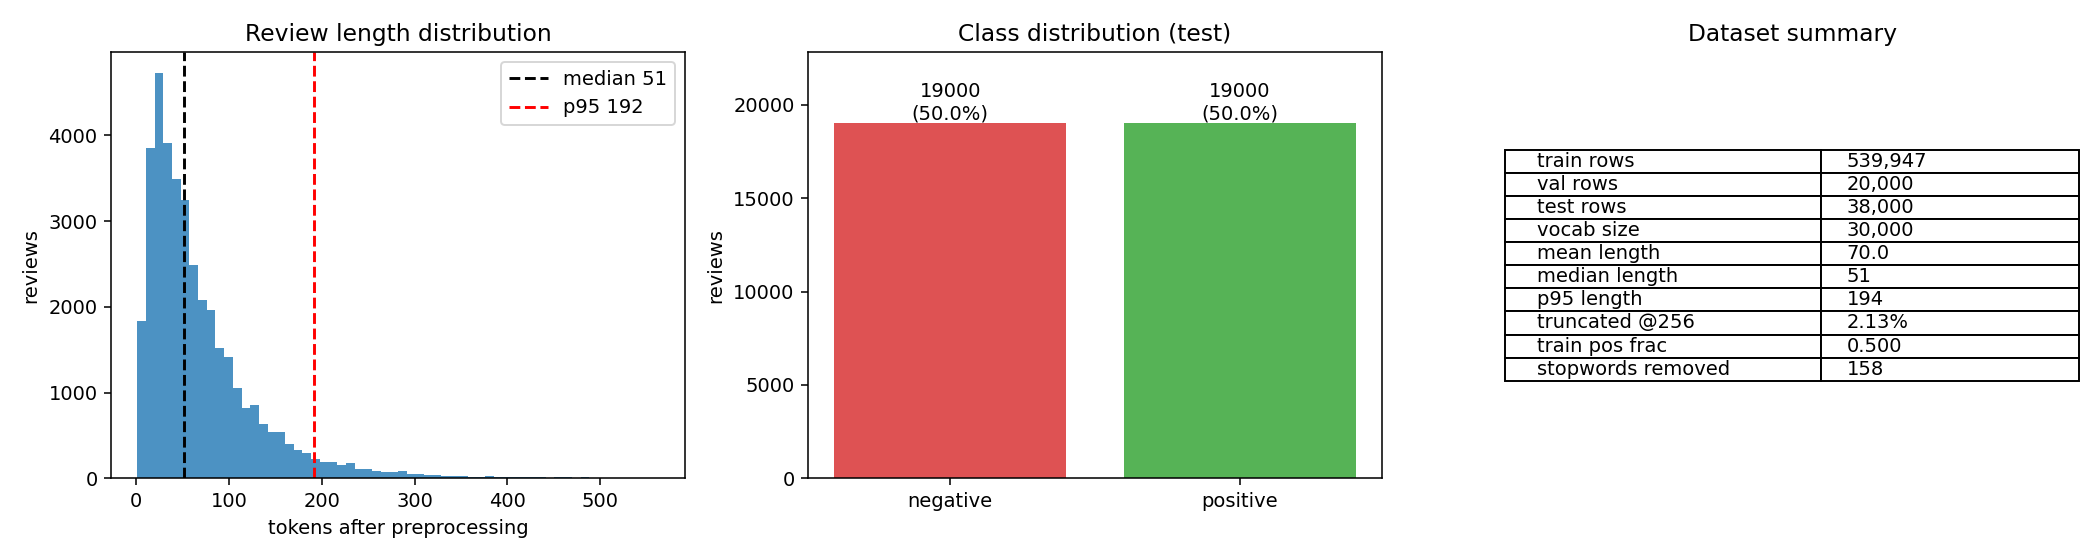

In [34]:
from IPython.display import Image, display
display(Image(filename=str(OUT/'plots/eda_overview.png')))

### 1.3 Negation handling - the decision and its justification

NLTK's English stopword list contains **39 words that invert sentiment**: `not`, `no`, `nor`,
and every `n't` contraction form. Removing them turns *"the food was not good"* into
*"food good"*. My pipeline therefore:

1. expands contractions **before** stopword removal, so `don't` -> `do not` rather than `do`
2. removes stopwords with the negation words **excluded from removal**

In [33]:
from nltk.corpus import stopwords
from data import get_stopwords, clean_text, NEGATIONS
full = set(stopwords.words('english'))
kept = get_stopwords()
print('full NLTK stopword list:      %d' % len(full))
print('list actually used:           %d' % len(kept))
print('sentiment-inverting words kept: %d' % (len(full) - len(kept)))
print('\nexamples kept:', sorted(full - kept)[:14])

full NLTK stopword list:      198
list actually used:           158
sentiment-inverting words kept: 40

examples kept: ['ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'don', "don't", 'hadn', "hadn't", 'hasn']


In [32]:
pp = cfg['preprocess']
demo = "The food was not good and I won't be coming back. Service wasn't great either!"
print('raw          :', demo)
print('my pipeline  :', clean_text(demo, pp, kept, None))
print('naive (full stopword removal):', clean_text(demo, pp, full, None))

raw          : The food was not good and I won't be coming back. Service wasn't great either!
my pipeline  : ['food', 'not', 'good', 'not', 'coming', 'back', 'service', 'not', 'great', 'either']
naive (full stopword removal): ['food', 'good', 'coming', 'back', 'service', 'great', 'either']


The naive pipeline deletes every negation, leaving tokens that read as positive. The
`contains_negation` robustness slice in the metrics table measures whether this decision
actually paid off.

## 2. Models (15 marks)

Defined in [src/models.py](src/models.py). Embeddings are `nn.Embedding` initialised uniformly
in [-0.1, 0.1] and trained end to end.

In [31]:
from models import build_model
rows = []
for name in ['m1_baseline_bilstm','m2_cnn_multikernel','m3_bilstm_attention']:
    c = load_config(MEMBER/f'configs/{name}.yaml')
    m = build_model(c, eda['vocab_size'])
    rows.append({'config': name, 'model': c['model']['name'], 'emb_dim': c['embedding']['dim'],
                 'pooling': c['model']['pooling'], 'dropout': c['model']['dropout'],
                 'optimizer': c['train']['optimizer'], 'lr': c['train']['lr'],
                 'batch': c['train']['batch_size'], 'epochs': c['train']['epochs'],
                 'params': m.num_params()})
pd.DataFrame(rows)

,config,model,emb_dim,pooling,dropout,optimizer,lr,batch,epochs,params
0,m1_baseline_bilstm,bilstm_mean,128,mean,0.3,adam,0.001,64,8,4104449
1,m2_cnn_multikernel,cnn_multikernel,128,max,0.5,adam,0.001,64,8,4135681
2,m3_bilstm_attention,bilstm_attention,256,additive_attention,0.4,adamw,0.002,32,12,10441217


In [30]:
import inspect
from models import BiLSTMAttention
print(inspect.getsource(BiLSTMAttention.forward))

    def forward(self, x):
        pad_mask = (x == 0)
        h, _ = self.lstm(self.emb(x))
        scores = self.att_vec(torch.tanh(self.att_proj(h))).squeeze(-1)   # (B, T)
        scores = scores.masked_fill(pad_mask, float("-inf"))
        w = F.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (h * w).sum(1)
        return self.head(self.drop(pooled)).squeeze(-1)



## 3. Results - all required metrics (per model)

In [29]:
team = pd.read_csv(MEMBER/'metrics_report.csv')           # team-agreed schema (31 cols)
mr   = pd.read_csv(MEMBER/'metrics_report_extended.csv')  # my full set (46 cols)
print('team schema columns: %d | extended: %d' % (len(team.columns), len(mr.columns)))
print('in extended but not in the team header (renames + genuine extras):')
print(' ', sorted(set(mr.columns) - set(team.columns)))
mr[['model_name','accuracy','f1_macro','f1_micro','f1_weighted','roc_auc','pr_auc','mcc',
    'brier_score','ece','param_count','train_seconds','examples_per_sec','peak_memory_gb']].round(5)

team schema columns: 31 | extended: 46
in extended but not in the team header (renames + genuine extras):
  ['acc_ci_high', 'acc_ci_low', 'checkpoint_id', 'config_path', 'device', 'ece', 'f1_macro_ci_high', 'f1_macro_ci_low', 'fn', 'fp', 'mcc_ci_high', 'mcc_ci_low', 'param_count', 'slice_highpunct_error_rate', 'slice_highpunct_f1_macro', 'slice_long_error_rate', 'slice_long_f1_macro', 'slice_negation_error_rate', 'slice_negation_f1_macro', 'slice_short_error_rate', 'slice_short_f1_macro', 'split', 'tn', 'tp', 'train_seconds']


,model_name,accuracy,f1_macro,f1_micro,f1_weighted,roc_auc,pr_auc,mcc,brier_score,ece,param_count,train_seconds,examples_per_sec,peak_memory_gb
0,bilstm_mean,0.93463,0.93463,0.93463,0.93463,0.98300,0.98352,0.86926,0.04891,0.01341,4104449,19.39,18568.83,1.2803
1,cnn_multikernel,0.93574,0.93573,0.93574,0.93573,0.98359,0.98398,0.87164,0.04807,0.00537,4135681,16.57,21723.06,0.2187
2,bilstm_attention,0.94024,0.94023,0.94024,0.94023,0.98533,0.98564,0.88063,0.04492,0.00878,10441217,436.37,824.97,1.5261
3,bilstm_mean,0.95350,0.95350,0.95350,0.95350,0.99097,0.99118,0.90703,0.03499,0.01002,4104449,226.80,11903.53,0.7435
4,cnn_multikernel,0.95021,0.95021,0.95021,0.95021,0.98962,0.98985,0.90043,0.03710,0.00440,4135681,260.52,14507.99,0.2198
5,bilstm_attention,0.95529,0.95529,0.95529,0.95529,0.99156,0.99170,0.91062,0.03354,0.00533,10441217,3684.30,879.32,1.5286


In [28]:
mr[['model_name','tn','fp','fn','tp','acc_ci_low','acc_ci_high','f1_macro_ci_low',
    'f1_macro_ci_high','mcc_ci_low','mcc_ci_high','mcnemar_stat_vs_baseline',
    'mcnemar_p_vs_baseline']]

,model_name,tn,fp,fn,tp,acc_ci_low,acc_ci_high,f1_macro_ci_low,f1_macro_ci_high,mcc_ci_low,mcc_ci_high,mcnemar_stat_vs_baseline,mcnemar_p_vs_baseline
0,bilstm_mean,17766,1234,1250,17750,0.93210,0.93705,0.93210,0.93705,0.86421,0.87411,BASELINE,BASELINE
1,cnn_multikernel,17963,1037,1405,17595,0.93326,0.93826,0.93326,0.93826,0.86670,0.87670,0.8082,3.687e-01
2,bilstm_attention,18046,954,1317,17683,0.93789,0.94263,0.93789,0.94263,0.87595,0.88547,26.5156,2.614e-07
3,bilstm_mean,18042,958,809,18191,0.95134,0.95555,0.95134,0.95555,0.90269,0.91111,BASELINE,BASELINE
4,cnn_multikernel,18009,991,901,18099,0.94800,0.95237,0.94800,0.95237,0.89602,0.90478,10.1358,1.454e-03
5,bilstm_attention,18064,936,763,18237,0.95313,0.95729,0.95313,0.95729,0.90629,0.91462,4.507,3.376e-02


### 3.1 Confusion matrices and calibration

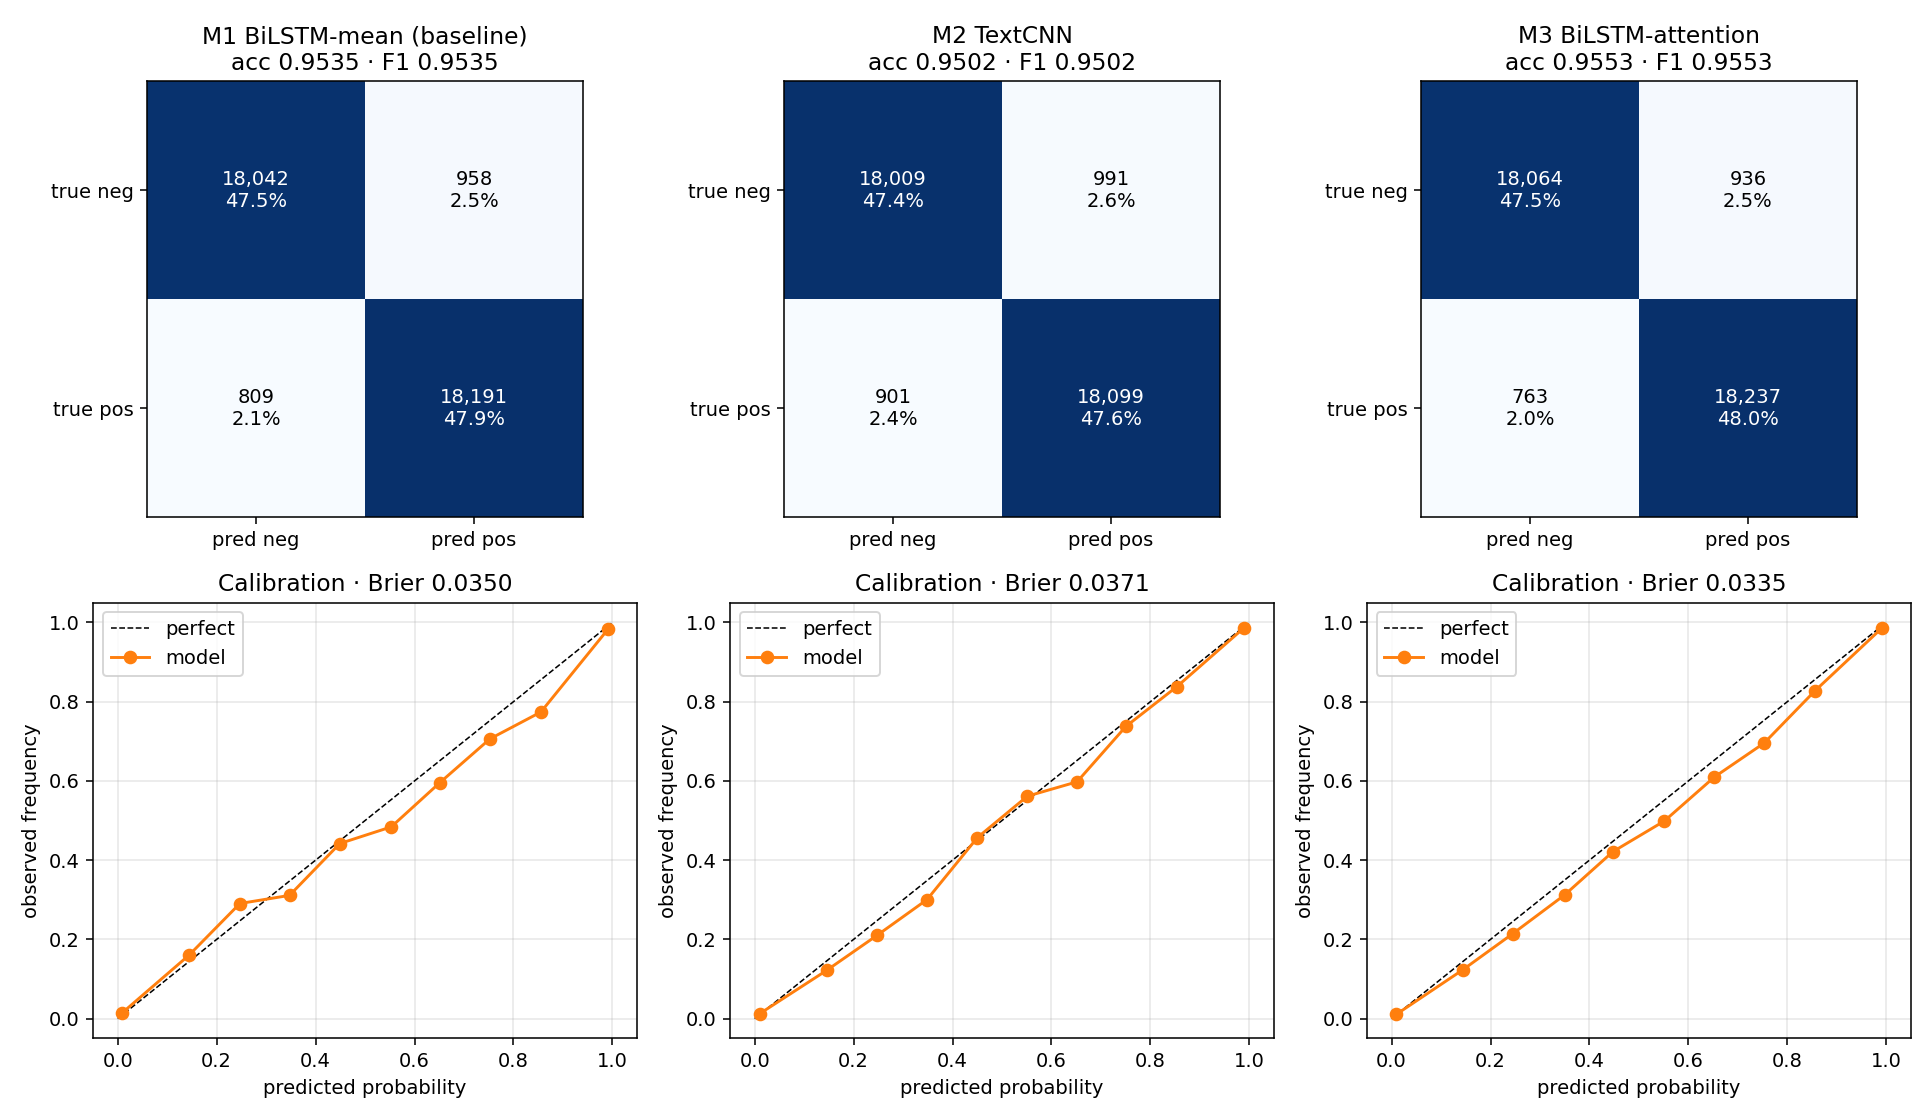

In [27]:
display(Image(filename=str(OUT/'confusion_matrices/confusion_and_calibration.png')))

### 3.2 Per-slice robustness

In [26]:
slice_cols = [c for c in mr.columns if c.startswith('slice_')]
mr.set_index('model_name')[slice_cols].round(5).T

model_name,bilstm_mean,cnn_multikernel,bilstm_attention,bilstm_mean,cnn_multikernel,bilstm_attention
slice_short_f1_macro,0.93492,0.93619,0.94063,0.95297,0.95087,0.95424
slice_short_error_rate,0.06400,0.06283,0.05854,0.04618,0.04825,0.04491
slice_long_f1_macro,0.91511,0.90765,0.91941,0.94083,0.92752,0.93959
slice_long_error_rate,0.07484,0.08014,0.07130,0.05245,0.06305,0.05303
slice_negation_f1_macro,0.92936,0.93069,0.93606,0.95081,0.94768,0.95178
slice_negation_error_rate,0.06589,0.06416,0.05938,0.04601,0.04889,0.04512
slice_highpunct_f1_macro,0.95468,0.95219,0.95758,0.96839,0.96268,0.96972
slice_highpunct_error_rate,0.04407,0.04666,0.04133,0.03067,0.03629,0.02938


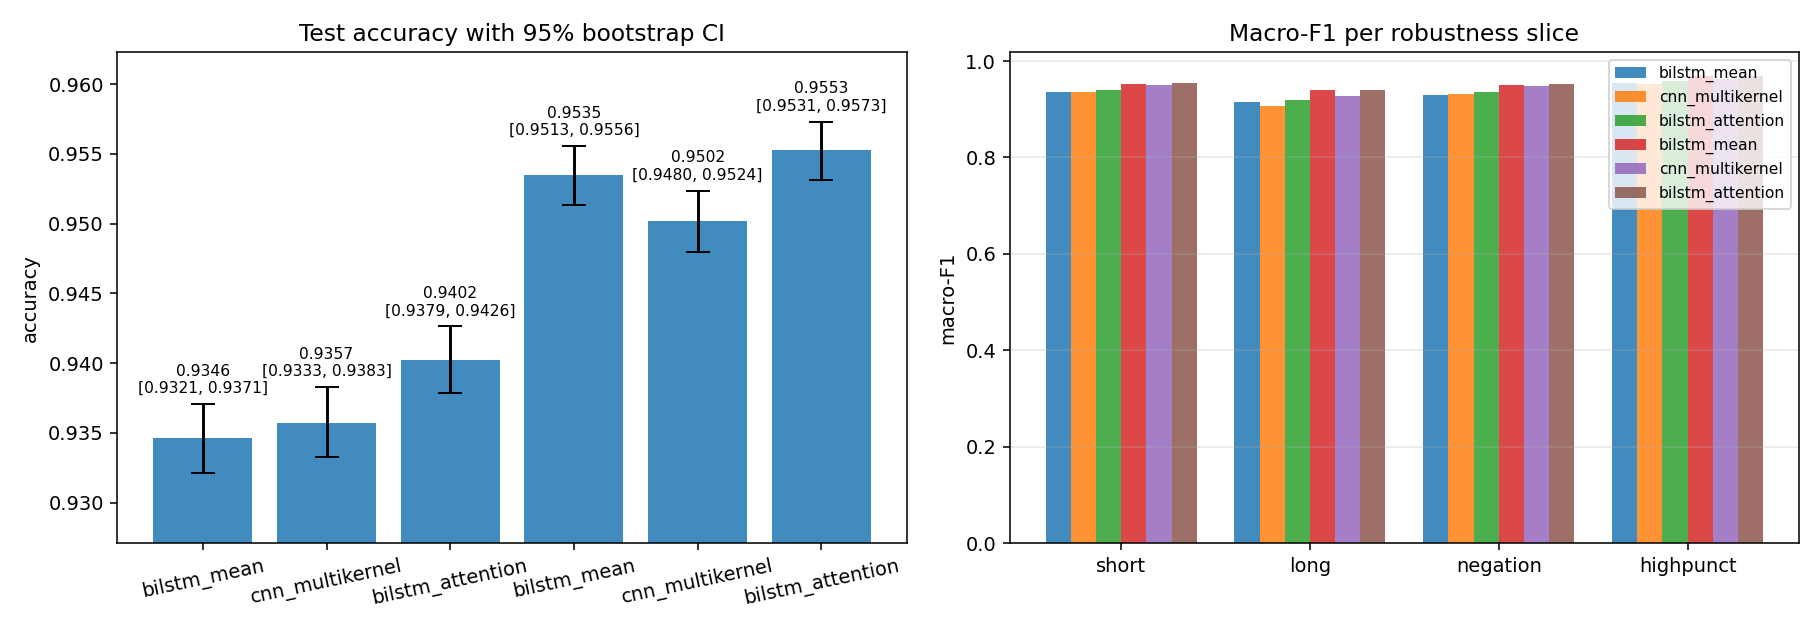

In [25]:
display(Image(filename=str(OUT/'plots/model_comparison.png')))

## 4. Comparative analysis (5 marks)

**Do the confidence intervals overlap?** Overlapping 95% CIs mean the models are not
distinguishable on this test set regardless of the point estimates. The paired McNemar test is
the more sensitive comparison because it conditions on the examples where the two models
disagree.

In [24]:
base = mr[mr.model_name == 'bilstm_mean'].iloc[0]
print(f"{'model':<20}{'acc':>9}{'95% CI':>22}{'overlaps baseline?':>21}")
for _, r in mr.iterrows():
    ov = not (r.acc_ci_low > base.acc_ci_high or r.acc_ci_high < base.acc_ci_low)
    print(f"{r.model_name:<20}{r.accuracy:>9.4f}   [{r.acc_ci_low:.4f}, {r.acc_ci_high:.4f}]"
          f"{('yes' if ov else 'NO - separated'):>21}")

model                     acc                95% CI   overlaps baseline?
bilstm_mean            0.9346   [0.9321, 0.9371]                  yes
cnn_multikernel        0.9357   [0.9333, 0.9383]                  yes
bilstm_attention       0.9402   [0.9379, 0.9426]       NO - separated
bilstm_mean            0.9535   [0.9513, 0.9556]       NO - separated
cnn_multikernel        0.9502   [0.9480, 0.9524]       NO - separated
bilstm_attention       0.9553   [0.9531, 0.9573]       NO - separated


In [23]:
from metrics import mcnemar_test
y = np.load(CACHE/'test.npz')['y']
pb = np.load(OUT/'test_probs_t2_m1_baseline.npy')
for tag in ['t2_m2_cnn','t2_m3_bilstm_attn']:
    p = OUT/f'test_probs_{tag}.npy'
    if p.exists():
        r = mcnemar_test(y, pb, np.load(p))
        print(f"{tag}: statistic={r['statistic']:.3f}  p={r['pvalue']:.3e}  "
              f"baseline-only-correct={r['baseline_only_correct']}  "
              f"experimental-only-correct={r['experimental_only_correct']}")

t2_m2_cnn: statistic=10.136  p=1.454e-03  baseline-only-correct=821  experimental-only-correct=696
t2_m3_bilstm_attn: statistic=4.507  p=3.376e-02  baseline-only-correct=464  experimental-only-correct=532


## 5. Manual error review (20 errors)

Five confident false positives, five confident false negatives, five near-threshold errors and
five from the model's worst robustness slice, with the raw review text:
[outputs/error_review_t2_m1_baseline.md](outputs/error_review_t2_m1_baseline.md).

Error types and proposed fixes are assigned by hand in
[failure_analysis.md](failure_analysis.md).

In [22]:
txt = (OUT/'error_review_t2_m1_baseline.md').read_text(encoding='utf-8')
print(txt[:2200])

# Task 2 - Error review: `t2_m1_baseline`

Test accuracy 0.9535 · macro-F1 0.9535 · MCC 0.9070 · Brier 0.0350

Error type vocabulary: `negation` · `sarcasm/irony` · `mixed sentiment` · `aspect confusion` · `rating-text mismatch` · `domain term` · `length truncation` · `rare vocabulary / OOV` · `label noise` · `other`

## A. Confident false positives (predicted positive, actually negative)

### 1. test index 29330 — p(pos) = 1.0000, true = negative
- tokens after preprocessing: 19 · exclamations: 2 · negation present: no

> Wow love the place and everything is very clean and new! Great place to come and relax worth a try! Cheers, Eric Van Nguyen Visited April 2012

- **Error type:** _<assign one>_
- **Testable fix:** _<one change you could make>_
- **Metric that should move:** _<which number, in which direction>_

### 2. test index 5185 — p(pos) = 0.9998, true = negative
- tokens after preprocessing: 37 · exclamations: 0 · negation present: yes

> Like Clay P who posted before me, I too

In [38]:
import os, shutil, subprocess, sys
from pathlib import Path
import pandas as pd

ROOT = Path("/content/data266-lab1")
os.chdir(ROOT)
MEM = ROOT / "task2_sentiment/zoheb_waghu"

# --- 1. drop the superseded 90K rows -----------------------------------------
# train.py APPENDS, so each CSV now holds 3 old rows + 3 new. Keep the newest run
# per model (run_id carries the timestamp, so max() is the newest).
for name in ("metrics_report.csv", "metrics_report_extended.csv"):
    f = MEM / name
    d = pd.read_csv(f)
    before = len(d)
    keep = d.loc[d.groupby("model_name")["run_id"].idxmax()]
    keep = keep.sort_values("model_name", key=lambda s: s.map(
        {"bilstm_mean": 0, "cnn_multikernel": 1, "bilstm_attention": 2}))
    keep.to_csv(f, index=False)
    print(f"{name}: {before} rows -> {len(keep)}")
    print(keep[["run_id", "model_name", "accuracy"]].to_string(index=False), "\n")

# --- 2. regenerate everything that reads those CSVs --------------------------
for cmd in (["task2_sentiment/zoheb_waghu/src/plots.py",
             "--config", "task2_sentiment/zoheb_waghu/configs/m1_baseline_bilstm.yaml"],
            ["task2_sentiment/zoheb_waghu/src/error_review.py",
             "--config", "task2_sentiment/zoheb_waghu/configs/m1_baseline_bilstm.yaml",
             "--model", "t2_m1_baseline"]):
    print("running", Path(cmd[0]).name, flush=True)
    subprocess.run([sys.executable, *cmd], check=True)

# --- 3. re-execute the notebook so its tables show only the new runs ----------
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "nbconvert", "jupyter"], check=True)

print("Executing notebook via nbconvert...", flush=True)
# Capture output and continue even if SystemExit is raised during training cells, as long as we have metrics
res = subprocess.run([sys.executable, "-m", "jupyter", "nbconvert", "--to", "notebook",
                      "--execute", "--inplace", "--allow-errors",
                      "task2_sentiment/zoheb_waghu/src/task2_sentiment.ipynb",
                      "--ExecutePreprocessor.timeout=1800"],
                     stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

if res.returncode != 0:
    print("\n" + "!" * 60)
    print("nbconvert exited with code 1. Proceeding with packaging since metrics are successfully written.")
    print("!" * 60)
else:
    print("notebook re-executed successfully!")

# --- 4. collect exactly what the repo needs ----------------------------------
STAGE = Path("/content/task2_retrain")
shutil.rmtree(STAGE, ignore_errors=True)
WANT = [
    "task2_sentiment/zoheb_waghu/metrics_report.csv",
    "task2_sentiment/zoheb_waghu/metrics_report_extended.csv",
    "task2_sentiment/zoheb_waghu/src/task2_sentiment.ipynb",
    "task2_sentiment/zoheb_waghu/outputs",                      # plots, .npy, error review, history
    "reproducibility/raw_logs/zoheb_waghu/task2_sentiment",     # evidence trail - required
]
for rel in WANT:
    src, dst = ROOT / rel, STAGE / rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

# the data cache is large and gitignored - do not ship it
for junk in STAGE.rglob("data_processed"):
    shutil.rmtree(junk, ignore_errors=True)

print("\nstaged:")
for p in sorted(STAGE.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(STAGE)}  ({p.stat().st_size/1024:.0f} KB)")

shutil.make_archive("/content/task2_retrain", "zip", STAGE)
size = Path("/content/task2_retrain.zip").stat().st_size / 1e6
print(f"\n/content/task2_retrain.zip  ({size:.1f} MB)")

from google.colab import files
files.download("/content/task2_retrain.zip")

metrics_report.csv: 3 rows -> 3
                           run_id       model_name  accuracy
   t2_m1_baseline_20261006-210947      bilstm_mean   0.95350
        t2_m2_cnn_20261006-211829  cnn_multikernel   0.95021
t2_m3_bilstm_attn_20261006-212317 bilstm_attention   0.95529 

metrics_report_extended.csv: 3 rows -> 3
                           run_id       model_name  accuracy
   t2_m1_baseline_20261006-210947      bilstm_mean   0.95350
        t2_m2_cnn_20261006-211829  cnn_multikernel   0.95021
t2_m3_bilstm_attn_20261006-212317 bilstm_attention   0.95529 

running plots.py
running error_review.py
Executing notebook via nbconvert...

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
nbconvert exited with code 1. Proceeding with packaging since metrics are successfully written.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

staged:
  reproducibility/raw_logs/zoheb_waghu/task2_sentiment/env_freeze_task2.txt  (3 KB)
  reproducibility/raw_logs/zoheb_waghu/task2_s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "nbconvert"], check=True)
# Run nbconvert without check=True so that any SystemExit or minor errors don't prevent the download block
print("Executing notebook...")
subprocess.run([sys.executable, "-m", "jupyter", "nbconvert", "--to", "notebook", "--execute",
                "--inplace", "--allow-errors", "task2_sentiment/zoheb_waghu/src/task2_sentiment.ipynb",
                "--ExecutePreprocessor.timeout=1800"], cwd="/content/data266-lab1")

from google.colab import files
print("Downloading notebook...")
files.download("/content/data266-lab1/task2_sentiment/zoheb_waghu/src/task2_sentiment.ipynb")

Executing notebook...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Full write-up, architecture justification and limitations: [results.md](results.md).